

*   **--------------------------------------------Name: Vanchanagiri Alekhya-----------------------------------------**
*   **----------------------------------------Enrollment Number: MML2025002----------------------------------------**

*   **------------------------------------GenAI & LLMs Assignment-4 AE & VAE
-----------------------------------------**


In [5]:
!pip install tensorflow matplotlib numpy
import tensorflow as tf
from tensorflow.keras import layers, models, backend as K
import numpy as np
import matplotlib.pyplot as plt


**Training Parameters**
---

In [15]:
BATCH_SIZE = 128
EPOCHS = 15
LEARNING_RATE = 0.001
IMG_SHAPE = (28, 28, 1)


**Loading Fashion-MNIST Dataset**
---

In [4]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


**Building AutoEncoder**
---

In [11]:

def build_ae(latent_dim, filters=[32, 64], activation="relu"):
    inp = layers.Input(shape=IMG_SHAPE)
    x = inp
    for f in filters:
        x = layers.Conv2D(f, 3, strides=2, padding="same", activation=activation)(x)
    x = layers.Flatten()(x)
    z = layers.Dense(latent_dim)(x)

    encoder = models.Model(inp, z)

    dec_in = layers.Input(shape=(latent_dim,))
    x = layers.Dense(7 * 7 * filters[-1], activation=activation)(dec_in)
    x = layers.Reshape((7, 7, filters[-1]))(x)
    for f in reversed(filters):
        x = layers.Conv2DTranspose(f, 3, strides=2, padding="same", activation=activation)(x)

    if x.shape[1] != 28:
      x = layers.Conv2DTranspose(32, 3, strides=2, padding="same", activation=activation)(x)
    out = layers.Conv2DTranspose(1, 3, padding="same", activation="sigmoid")(x)

    decoder = models.Model(dec_in, out)
    ae = models.Model(inp, decoder(encoder(inp)))
    ae.compile(optimizer=tf.keras.optimizers.Adam(LEARNING_RATE), loss="mse")
    return ae, encoder, decoder

**Building VAE:**
---


In [25]:

class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        eps = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * eps

def build_vae(latent_dim, filters=[32, 64], activation="relu"):
    inp = layers.Input(shape=IMG_SHAPE)
    x = inp
    for f in filters:
        x = layers.Conv2D(f, 3, strides=2, padding="same", activation=activation)(x)
    x = layers.Flatten()(x)

    z_mean = layers.Dense(latent_dim)(x)
    z_log_var = layers.Dense(latent_dim)(x)
    z = Sampling()([z_mean, z_log_var])

    encoder = models.Model(inp, [z_mean, z_log_var, z])

    dec_in = layers.Input(shape=(latent_dim,))
    x = layers.Dense(7 * 7 * filters[-1], activation=activation)(dec_in)
    x = layers.Reshape((7, 7, filters[-1]))(x)
    for f in reversed(filters):
        x = layers.Conv2DTranspose(f, 3, strides=2, padding="same", activation=activation)(x)
    if x.shape[1] != 28:
        x = layers.Conv2DTranspose(
            filters[-1],
            3,
            strides=2,
            padding="same",
            activation=activation
        )(x)
    out = layers.Conv2DTranspose(1, 3, strides=1, padding="same", activation="sigmoid")(x)




    decoder = models.Model(dec_in, out)
    out_img = decoder(z)
    vae = models.Model(inp, out_img)

    recon_loss = tf.reduce_mean(tf.keras.losses.mse(K.flatten(inp), K.flatten(out_img)))
    kl_loss = -0.5 * tf.reduce_mean(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))

    vae.add_loss(recon_loss + kl_loss)
    vae.add_metric(recon_loss, name="recon_loss")
    vae.add_metric(kl_loss, name="kl_loss")
    vae.compile(optimizer=tf.keras.optimizers.Adam(LEARNING_RATE))
    return vae, encoder, decoder

In [31]:
class VAE(tf.keras.Model):
    def __init__(self, latent_dim, filters=[32, 64], activation="relu"):
        super().__init__()

        self.encoder_conv = []
        for f in filters:
            self.encoder_conv.append(
                layers.Conv2D(f, 3, strides=2, padding="same", activation=activation)
            )
        self.flatten = layers.Flatten()
        self.z_mean_layer = layers.Dense(latent_dim)
        self.z_log_var_layer = layers.Dense(latent_dim)
        self.sampling = Sampling()

        current_feature_map_size = 7
        target_feature_map_size = 28

        self.decoder_dense = layers.Dense(current_feature_map_size * current_feature_map_size * filters[-1], activation=activation)
        self.decoder_reshape = layers.Reshape((current_feature_map_size, current_feature_map_size, filters[-1]))

        self.decoder_conv = []

        for f in reversed(filters):
            self.decoder_conv.append(layers.Conv2DTranspose(f, 3, strides=2, padding="same", activation=activation))
            current_feature_map_size *= 2

        while current_feature_map_size < target_feature_map_size:
            self.decoder_conv.append(layers.Conv2DTranspose(
                filters[0] if filters else 32,
                3,
                strides=2,
                padding="same",
                activation=activation
            ))
            current_feature_map_size *= 2

        self.decoder_out = layers.Conv2DTranspose(
            1, 3, padding="same", activation="sigmoid"
        )

        self.activation = activation

        self.recon_loss_tracker = tf.keras.metrics.Mean(name="recon_loss")
        self.kl_loss_tracker = tf.keras.metrics.Mean(name="kl_loss")

    def encode(self, x):
        for layer in self.encoder_conv:
            x = layer(x)
        x = self.flatten(x)
        z_mean = self.z_mean_layer(x)
        z_log_var = self.z_log_var_layer(x)
        z = self.sampling((z_mean, z_log_var))
        return z_mean, z_log_var, z

    def decode(self, z):
        x = self.decoder_dense(z)
        x = self.decoder_reshape(x)
        for layer in self.decoder_conv:
            x = layer(x)

        return self.decoder_out(x)

    def call(self, inputs):
        z_mean, z_log_var, z = self.encode(inputs)
        reconstruction = self.decode(z)

        recon_loss = tf.reduce_mean(
            tf.keras.losses.mse(
                tf.reshape(inputs, [tf.shape(inputs)[0], -1]),
                tf.reshape(reconstruction, [tf.shape(reconstruction)[0], -1])
            )
        )

        kl_loss = -0.5 * tf.reduce_mean(
            1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var)
        )

        self.add_loss(recon_loss + kl_loss)

        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return reconstruction

    @property
    def metrics(self):
        return [self.recon_loss_tracker, self.kl_loss_tracker]


**Visulaization:**
---

In [14]:

def plot_reconstruction(model, title):
    recon = model.predict(x_test[:10])
    plt.figure(figsize=(12,3))
    for i in range(10):
        plt.subplot(2,10,i+1)
        plt.imshow(x_test[i].squeeze(), cmap="gray")
        plt.axis("off")
        plt.subplot(2,10,i+11)
        plt.imshow(recon[i].squeeze(), cmap="gray")
        plt.axis("off")
    plt.suptitle(title)
    plt.show()

def plot_latent(encoder, title):
    z, _, _ = encoder.predict(x_test[:5000]) if len(encoder.output) == 3 else (encoder.predict(x_test[:5000]), None, None)
    plt.scatter(z[:,0], z[:,1], s=2)
    plt.title(title)
    plt.show()

def generate_vae(decoder, latent_dim):
    z = np.random.normal(size=(10, latent_dim))
    gen = decoder.predict(z)
    plt.figure(figsize=(10,2))
    for i in range(10):
        plt.subplot(1,10,i+1)
        plt.imshow(gen[i].squeeze(), cmap="gray")
        plt.axis("off")
    plt.show()

**Experiments**
---

**A. Model Comparison:**
---


Training AE with latent dimension = 64
Epoch 1/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 0.0610 - val_loss: 0.0140
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0127 - val_loss: 0.0101
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0095 - val_loss: 0.0085
Epoch 4/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0081 - val_loss: 0.0075
Epoch 5/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0073 - val_loss: 0.0069
Epoch 6/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0067 - val_loss: 0.0066
Epoch 7/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0064 - val_loss: 0.0062
Epoch 8/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0060 - val_loss: 0.0060
Epoch 9/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0058 - val_loss: 0.0059
Epoch 10/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0056 - val_loss: 0.0057
Epoch 11/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0055 - val_loss: 0.0056
Epoch 12/15

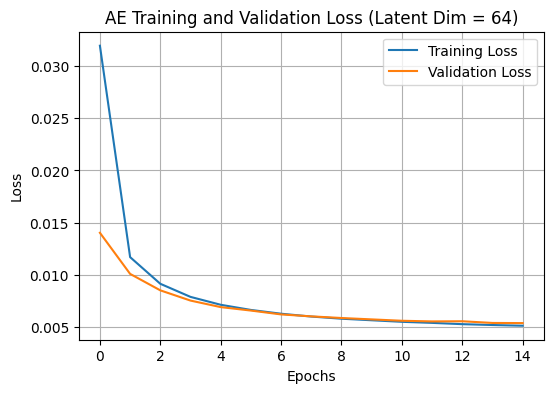

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 473ms/step


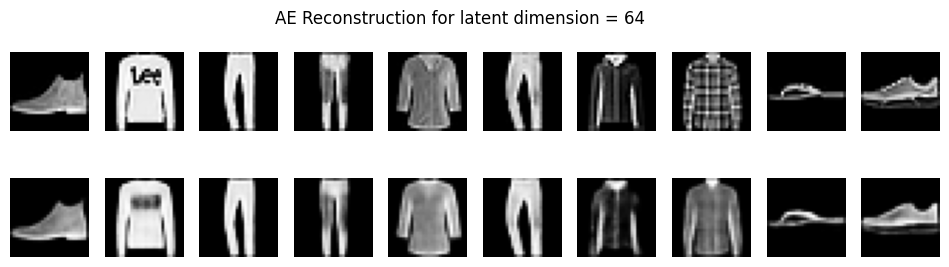


Training VAE with latent dimension = 64
Epoch 1/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - kl_loss: 0.0032 - recon_loss: 0.1018 - val_kl_loss: 0.0102 - val_recon_loss: 0.0716
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - kl_loss: 0.0111 - recon_loss: 0.0701 - val_kl_loss: 0.0131 - val_recon_loss: 0.0662
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - kl_loss: 0.0142 - recon_loss: 0.0646 - val_kl_loss: 0.0159 - val_recon_loss: 0.0612
Epoch 4/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - kl_loss: 0.0157 - recon_loss: 0.0607 - val_kl_loss: 0.0176 - val_recon_loss: 0.0573
Epoch 5/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - kl_loss: 0.0171 - recon_loss: 0.0575 - val_kl_loss: 0.0184 - val_recon_loss: 0.0563
Epoch 6/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - kl_loss: 0.0179 - recon_loss: 0.0567 - val_kl_loss: 0.0188 - val_recon_loss: 0.0554
Epoch 7/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - kl_loss: 0.0182 - recon_loss: 0.0558 - val_kl_loss: 0.0170 - val_recon_lo

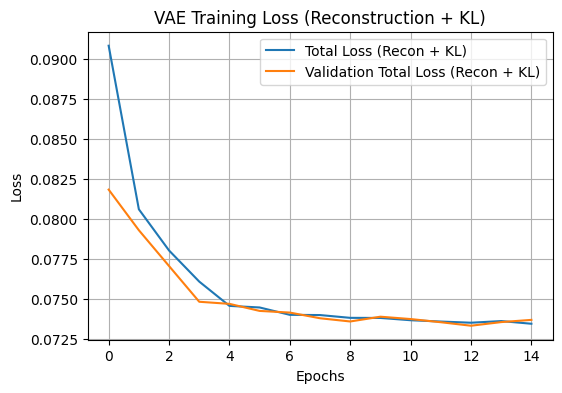

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 996ms/step


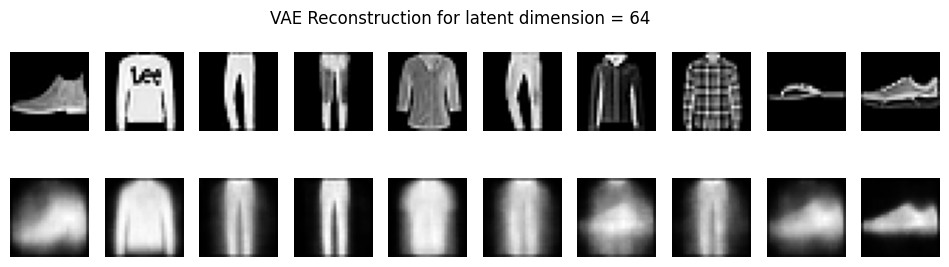

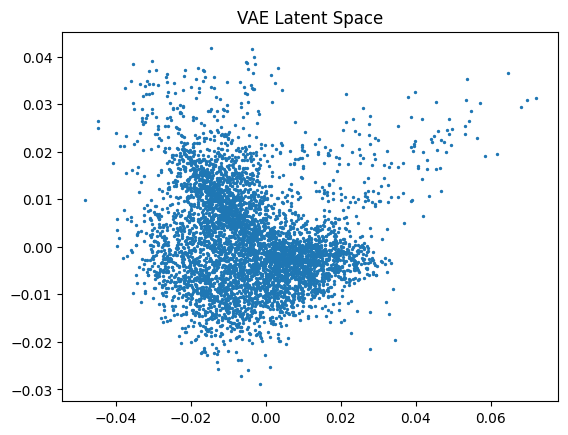


Generating images using VAE:


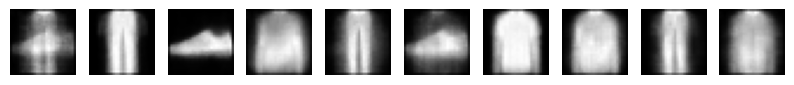

In [20]:
experiments = [
    {"model_type": "AE", "latent_dim": 64},
    {"model_type": "VAE", "latent_dim": 64}
]

for exp in experiments:
    if exp["model_type"] == "AE":
        print("\nTraining AE with latent dimension = 64")
        model, enc, dec = build_ae(exp["latent_dim"])

        history = model.fit(
            x_train,
            x_train,
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            validation_split=0.2
        )

        plt.figure(figsize=(6,4))
        plt.plot(history.history["loss"], label="Training Loss")
        plt.plot(history.history["val_loss"], label="Validation Loss")
        plt.xlabel("Epochs")
        plt.ylabel("Loss")
        plt.title("AE Training and Validation Loss (Latent Dim = 64)")
        plt.legend()
        plt.grid(True)
        plt.show()


        plot_reconstruction(model, "AE Reconstruction for latent dimension = 64")



    else:
        print("\nTraining VAE with latent dimension = 64")
        model = VAE(exp["latent_dim"])
        model.compile(optimizer=tf.keras.optimizers.Adam(LEARNING_RATE))
        history = model.fit(
            x_train,
            x_train,
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            validation_split=0.2
        )

        plt.figure(figsize=(6,4))

        total_vae_loss = np.array(history.history["recon_loss"]) + np.array(history.history["kl_loss"])
        plt.plot(total_vae_loss, label="Total Loss (Recon + KL)")

        if "val_recon_loss" in history.history and "val_kl_loss" in history.history:
            total_vae_val_loss = np.array(history.history["val_recon_loss"]) + np.array(history.history["val_kl_loss"])
            plt.plot(total_vae_val_loss, label="Validation Total Loss (Recon + KL)")
        plt.xlabel("Epochs")
        plt.ylabel("Loss")
        plt.title("VAE Training Loss (Reconstruction + KL)")
        plt.legend()
        plt.grid(True)
        plt.show()

        plot_reconstruction(model, "VAE Reconstruction for latent dimension = 64")

        z_mean, _, _ = model.encode(x_test[:5000])
        plt.scatter(z_mean[:, 0], z_mean[:, 1], s=2)
        plt.title("VAE Latent Space")
        plt.show()


        z = np.random.normal(size=(10, exp["latent_dim"]))
        print("\nGenerating images using VAE:")
        gen = model.decode(z)
        plt.figure(figsize=(10,2))
        for i in range(10):
            plt.subplot(1,10,i+1)
            plt.imshow(gen[i].numpy().squeeze(), cmap="gray")
            plt.axis("off")
        plt.show()

Observations(Model Comparison)
---



1.   The Autoencoder (AE) produces sharper and clearer reconstructions than the VAE.
1.   AE trains faster and achieves a lower reconstruction loss.
2.   The VAE reconstructions are slightly blurry, since it also enforces latent space regularization.
1.   VAE learns a smooth and continuous latent space, making it suitable for generating new images.
2.   Random sampling works well for VAE but fails for AE.

Conclusion:
AE is better for reconstruction, while VAE is better for representation learning and generation.

**B. Latent Space Analysis:**
---


Latent Dimension = 16
Training Autoencoder (AE)...
Epoch 1/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - loss: 0.0598 - val_loss: 0.0140
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0127 - val_loss: 0.0101
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0096 - val_loss: 0.0085
Epoch 4/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0081 - val_loss: 0.0075
Epoch 5/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 0.0072 - val_loss: 0.0069
Epoch 6/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0066 - val_loss: 0.0065
Epoch 7/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0063 - val_loss: 0.0062
Epoch 8/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0060 - val_loss: 0.0061
Epoch 9/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0058 - val_loss: 0.0059
Epoch 10/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0056 - val_loss: 0.0057
Epoch 11/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0055 - val_loss: 0.0056

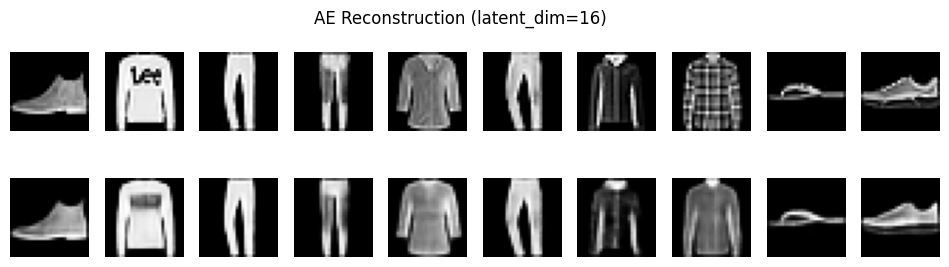

Visualizing AE latent space...
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


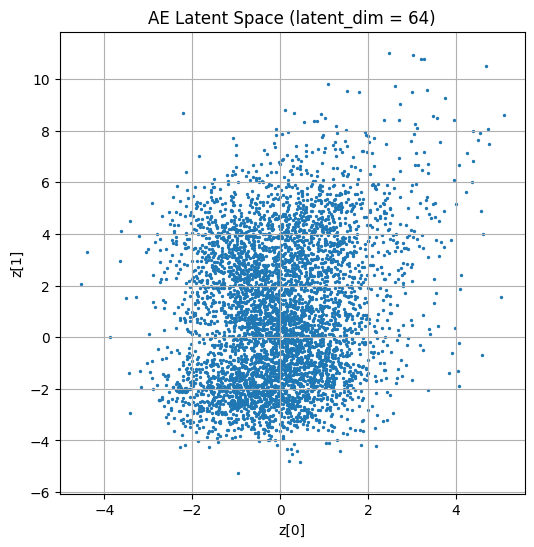

Training Variational Autoencoder (VAE)...
Epoch 1/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - kl_loss: 3.6521e-04 - recon_loss: 0.1061 - val_kl_loss: 1.9349e-04 - val_recon_loss: 0.0877
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - kl_loss: 2.5393e-04 - recon_loss: 0.0875 - val_kl_loss: 1.5601e-04 - val_recon_loss: 0.0876
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - kl_loss: 1.6792e-04 - recon_loss: 0.0872 - val_kl_loss: 1.3970e-04 - val_recon_loss: 0.0873
Epoch 4/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - kl_loss: 1.5069e-04 - recon_loss: 0.0874 - val_kl_loss: 1.4669e-04 - val_recon_loss: 0.0872
Epoch 5/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - kl_loss: 1.1423e-04 - recon_loss: 0.0873 - val_kl_loss: 9.9313e-05 - val_recon_loss: 0.0873
Epoch 6/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - kl_loss: 1.0321e-04 - recon_loss: 0.0872 - val_kl_loss: 9.0404e-05 - val_recon_loss: 0.0872
Epoch 7/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - kl_loss: 9.0952e-05 - reco

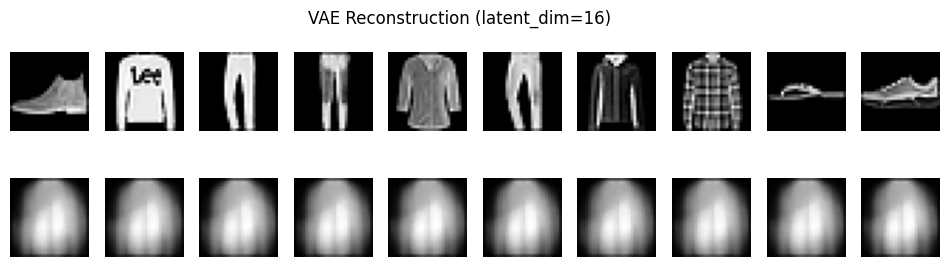

Visualizing latent space...


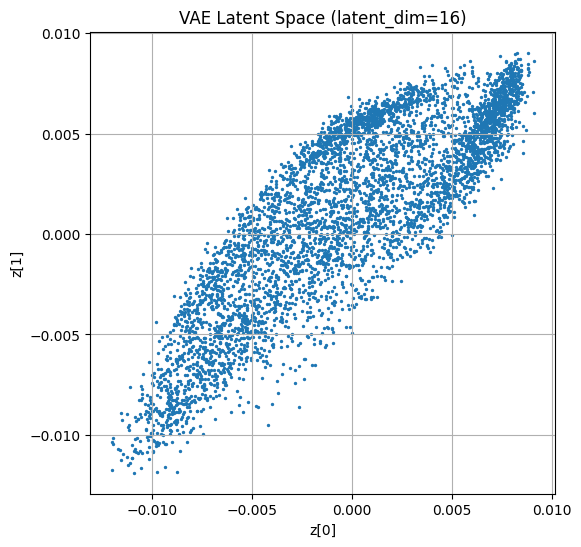

Generating new samples from VAE...


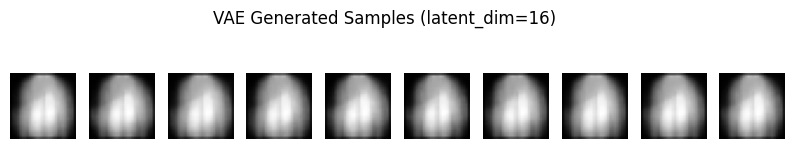


Latent Dimension = 32
Training Autoencoder (AE)...
Epoch 1/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - loss: 0.0576 - val_loss: 0.0135
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0123 - val_loss: 0.0099
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0093 - val_loss: 0.0083
Epoch 4/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0079 - val_loss: 0.0074
Epoch 5/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 0.0072 - val_loss: 0.0070
Epoch 6/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0066 - val_loss: 0.0065
Epoch 7/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0062 - val_loss: 0.0062
Epoch 8/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0060 - val_loss: 0.0060
Epoch 9/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0057 - val_loss: 0.0059
Epoch 10/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0056 - val_loss: 0.0057
Epoch 11/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0054 - val_loss: 0.0056

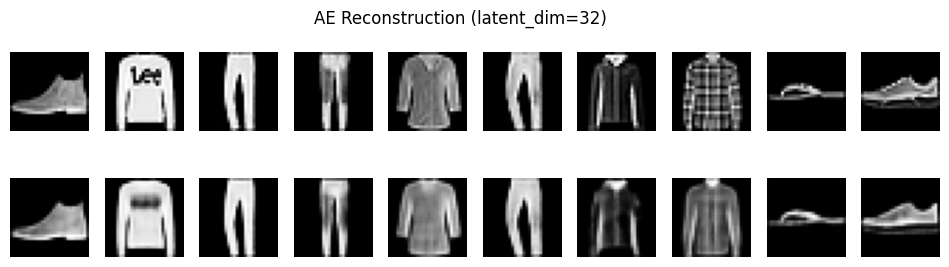

Visualizing AE latent space...
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


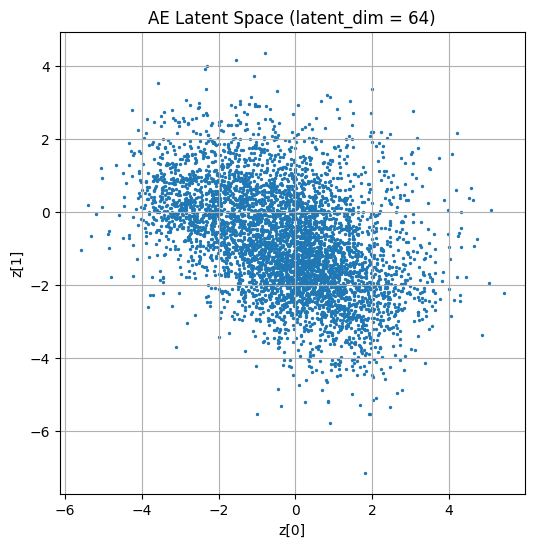

Training Variational Autoencoder (VAE)...
Epoch 1/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - kl_loss: 6.6972e-04 - recon_loss: 0.1049 - val_kl_loss: 0.0021 - val_recon_loss: 0.0860
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - kl_loss: 0.0032 - recon_loss: 0.0841 - val_kl_loss: 0.0043 - val_recon_loss: 0.0825
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - kl_loss: 0.0047 - recon_loss: 0.0821 - val_kl_loss: 0.0047 - val_recon_loss: 0.0817
Epoch 4/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - kl_loss: 0.0047 - recon_loss: 0.0816 - val_kl_loss: 0.0047 - val_recon_loss: 0.0815
Epoch 5/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - kl_loss: 0.0049 - recon_loss: 0.0813 - val_kl_loss: 0.0051 - val_recon_loss: 0.0811
Epoch 6/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - kl_loss: 0.0051 - recon_loss: 0.0806 - val_kl_loss: 0.0054 - val_recon_loss: 0.0810
Epoch 7/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - kl_loss: 0.0052 - recon_loss: 0.0807 - val_kl_loss: 0.0065 - val_recon

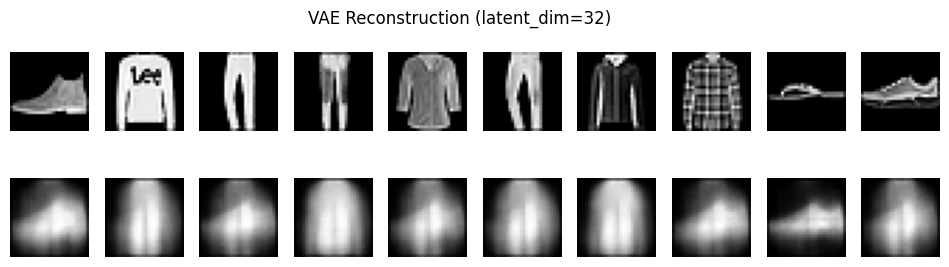

Visualizing latent space...


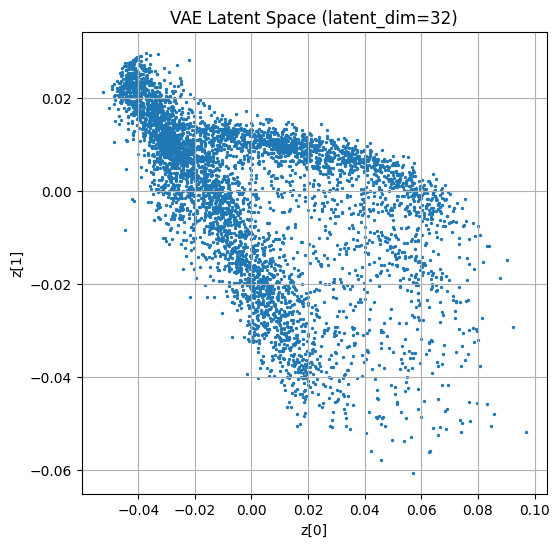

Generating new samples from VAE...


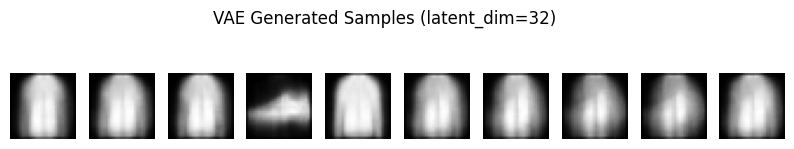


Latent Dimension = 64
Training Autoencoder (AE)...
Epoch 1/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 0.0608 - val_loss: 0.0137
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.0125 - val_loss: 0.0099
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0094 - val_loss: 0.0085
Epoch 4/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0081 - val_loss: 0.0075
Epoch 5/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0072 - val_loss: 0.0070
Epoch 6/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0067 - val_loss: 0.0066
Epoch 7/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0064 - val_loss: 0.0064
Epoch 8/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0061 - val_loss: 0.0061
Epoch 9/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0059 - val_loss: 0.0060
Epoch 10/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0057 - val_loss: 0.0058
Epoch 11/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0056 - val_loss: 0.

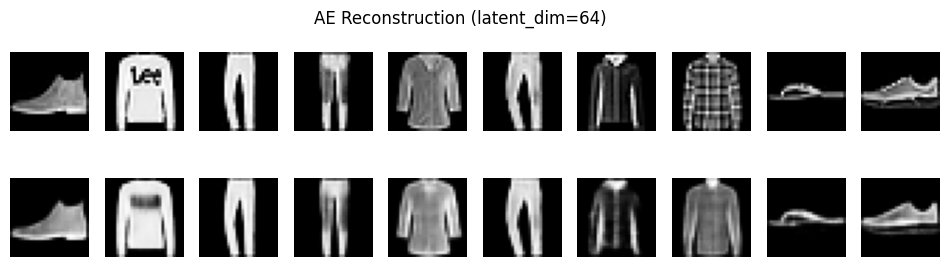

Visualizing AE latent space...
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


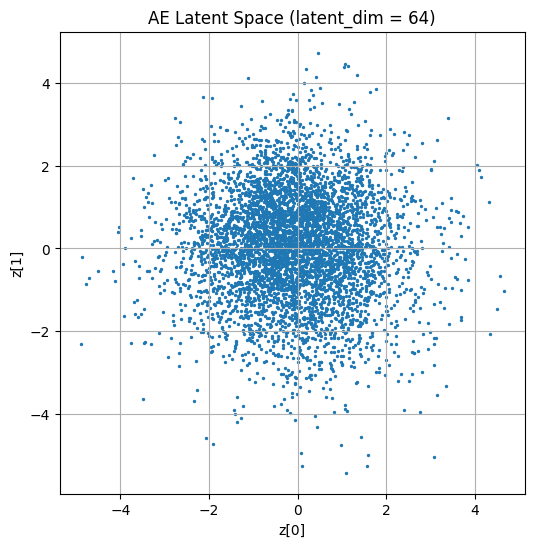

Training Variational Autoencoder (VAE)...
Epoch 1/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - kl_loss: 0.0034 - recon_loss: 0.1016 - val_kl_loss: 0.0106 - val_recon_loss: 0.0708
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - kl_loss: 0.0109 - recon_loss: 0.0697 - val_kl_loss: 0.0120 - val_recon_loss: 0.0672
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - kl_loss: 0.0134 - recon_loss: 0.0647 - val_kl_loss: 0.0155 - val_recon_loss: 0.0616
Epoch 4/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - kl_loss: 0.0146 - recon_loss: 0.0617 - val_kl_loss: 0.0164 - val_recon_loss: 0.0588
Epoch 5/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - kl_loss: 0.0167 - recon_loss: 0.0584 - val_kl_loss: 0.0171 - val_recon_loss: 0.0577
Epoch 6/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - kl_loss: 0.0175 - recon_loss: 0.0568 - val_kl_loss: 0.0178 - val_recon_loss: 0.0565
Epoch 7/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - kl_loss: 0.0181 - recon_loss: 0.0559 - val_kl_loss: 0.0188 - val_recon_los

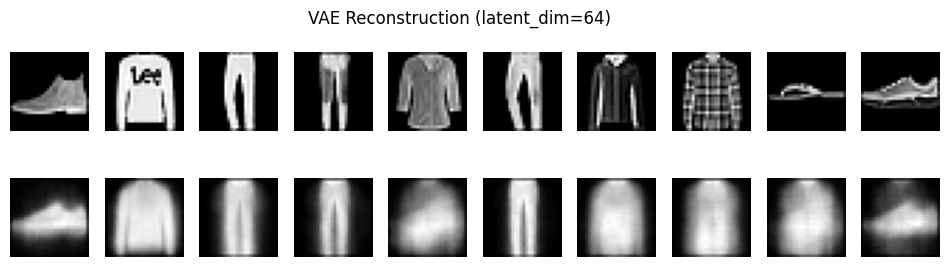

Visualizing latent space...


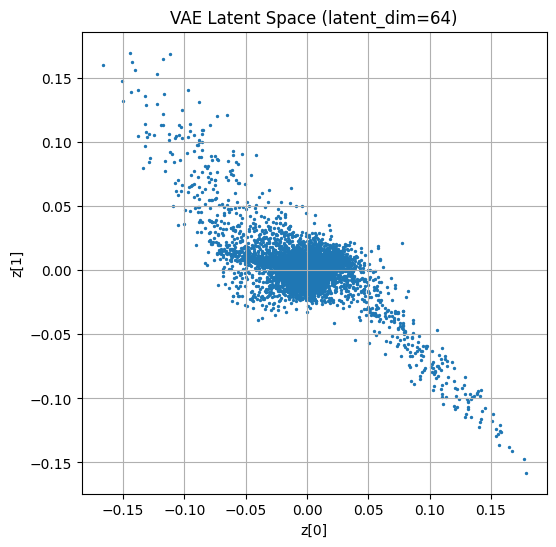

Generating new samples from VAE...


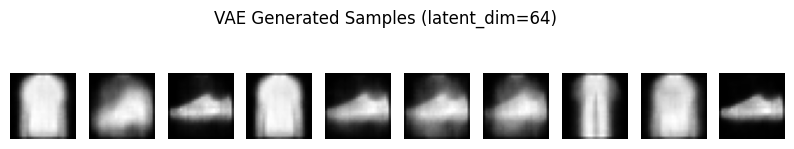


Latent Dimension = 128
Training Autoencoder (AE)...
Epoch 1/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 0.0625 - val_loss: 0.0142
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0127 - val_loss: 0.0104
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0096 - val_loss: 0.0084
Epoch 4/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0082 - val_loss: 0.0076
Epoch 5/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0073 - val_loss: 0.0070
Epoch 6/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0068 - val_loss: 0.0068
Epoch 7/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0064 - val_loss: 0.0063
Epoch 8/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0061 - val_loss: 0.0061
Epoch 9/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0059 - val_loss: 0.0060
Epoch 10/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0057 - val_loss: 0.0058
Epoch 11/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0055 - val_loss: 0.00

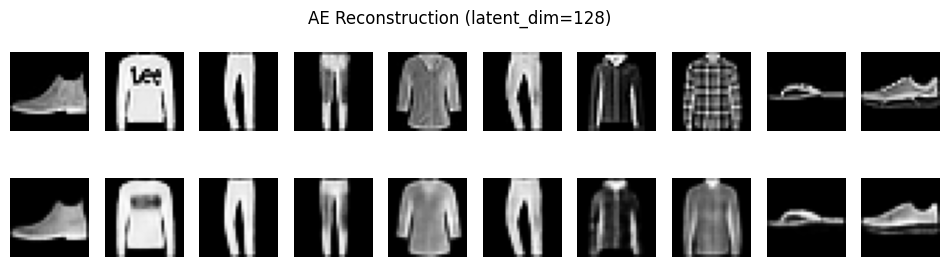

Visualizing AE latent space...
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


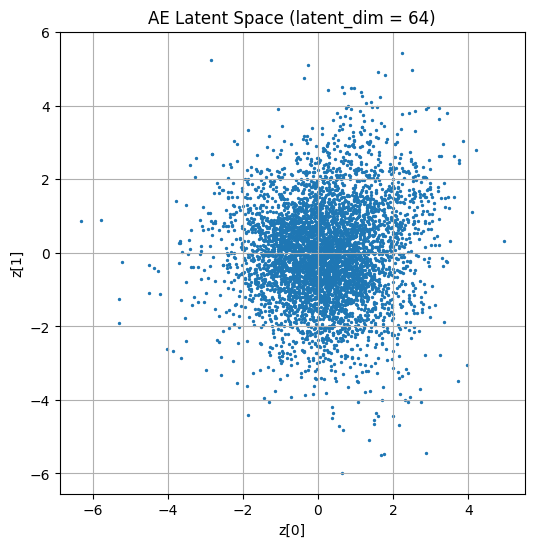

Training Variational Autoencoder (VAE)...
Epoch 1/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - kl_loss: 0.0052 - recon_loss: 0.0962 - val_kl_loss: 0.0121 - val_recon_loss: 0.0617
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - kl_loss: 0.0131 - recon_loss: 0.0598 - val_kl_loss: 0.0129 - val_recon_loss: 0.0588
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - kl_loss: 0.0145 - recon_loss: 0.0557 - val_kl_loss: 0.0161 - val_recon_loss: 0.0500
Epoch 4/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - kl_loss: 0.0158 - recon_loss: 0.0493 - val_kl_loss: 0.0167 - val_recon_loss: 0.0463
Epoch 5/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - kl_loss: 0.0167 - recon_loss: 0.0460 - val_kl_loss: 0.0164 - val_recon_loss: 0.0455
Epoch 6/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - kl_loss: 0.0172 - recon_loss: 0.0444 - val_kl_loss: 0.0185 - val_recon_loss: 0.0429
Epoch 7/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - kl_loss: 0.0176 - recon_loss: 0.0434 - val_kl_loss: 0.0178 - val_rec

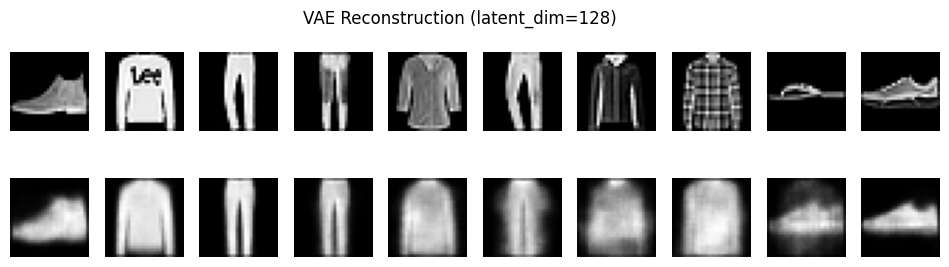

Visualizing latent space...


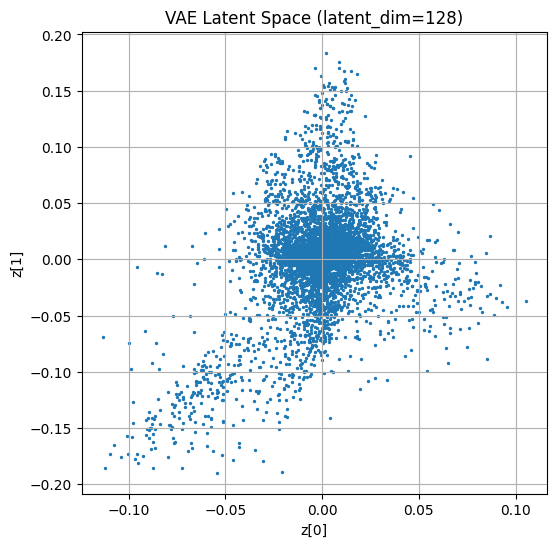

Generating new samples from VAE...


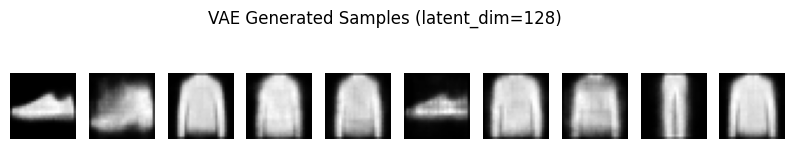

In [23]:

latent_dims = [16, 32, 64, 128]

for ld in latent_dims:
    print("\n" + "=" * 50)
    print(f"Latent Dimension = {ld}")
    print("=" * 50)
    print("Training Autoencoder (AE)...")

    ae, encoder, decoder = build_ae(latent_dim=64)


    ae.compile(
        optimizer=tf.keras.optimizers.Adam(LEARNING_RATE),
        loss="mse"
    )

    ae.fit(
        x_train,
        x_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=0.2,
        verbose=1
    )
    plot_reconstruction(
        ae,
        title=f"AE Reconstruction (latent_dim={ld})"
    )

    print("Visualizing AE latent space...")
    z_ae = encoder.predict(x_test[:5000])


    plt.figure(figsize=(6, 6))
    plt.scatter(z_ae[:, 0], z_ae[:, 1], s=2)
    plt.xlabel("z[0]")
    plt.ylabel("z[1]")
    plt.title("AE Latent Space (latent_dim = {ld})")
    plt.grid(True)
    plt.show()

    print("Training Variational Autoencoder (VAE)...")

    vae = VAE(latent_dim=ld)
    vae.compile(
        optimizer=tf.keras.optimizers.Adam(LEARNING_RATE)
    )

    vae.fit(
        x_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=0.2,
        verbose=1
    )

    plot_reconstruction(
        vae,
        title=f"VAE Reconstruction (latent_dim={ld})"
    )
    print("Visualizing latent space...")

    z_mean, _, _ = vae.encode(x_test[:5000])

    plt.figure(figsize=(6, 6))
    plt.scatter(z_mean[:, 0], z_mean[:, 1], s=2)
    plt.xlabel("z[0]")
    plt.ylabel("z[1]")
    plt.title(f"VAE Latent Space (latent_dim={ld})")
    plt.grid(True)
    plt.show()

    print("Generating new samples from VAE...")

    z = np.random.normal(size=(10, ld))
    generated = vae.decode(z)

    plt.figure(figsize=(10, 2))
    for i in range(10):
        plt.subplot(1, 10, i + 1)
        plt.imshow(generated[i].numpy().squeeze(), cmap="gray")
        plt.axis("off")

    plt.suptitle(f"VAE Generated Samples (latent_dim={ld})")
    plt.show()


Observations(Latent space analysis)
---




1.   Smaller latent dimensions (e.g., 16) limit information capacity, leading to poor reconstructions.

1.   Increasing the latent size (32, 64, 128) improves reconstruction quality.

1.   AE latent space appears scattered and irregular.
2.   VAE latent space is well-structured and smooth, following a Gaussian distribution.


2.   A latent dimension of 64 provides a good balance between quality and structure.















**C. Architecture Variations:**
---


Architecture: Filters=[32] | Activation=relu
Training Autoencoder (AE)...
Epoch 1/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.0655 - val_loss: 0.0144
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0130 - val_loss: 0.0102
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0096 - val_loss: 0.0086
Epoch 4/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0083 - val_loss: 0.0077
Epoch 5/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0074 - val_loss: 0.0072
Epoch 6/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0069 - val_loss: 0.0068
Epoch 7/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0066 - val_loss: 0.0066
Epoch 8/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0064 - val_loss: 0.0064
Epoch 9/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0062 - val_loss: 0.0062
Epoch 10/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0060 - val_loss: 0.0061
Epoch 11/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0

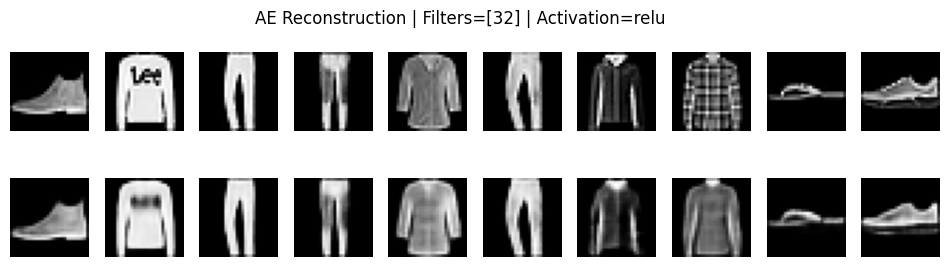

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


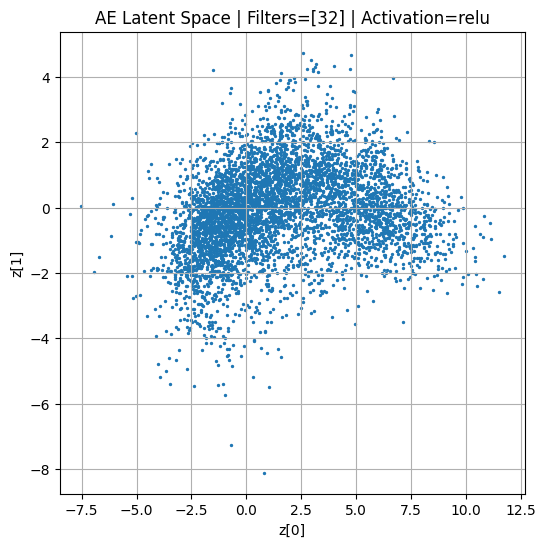

Training Variational Autoencoder (VAE)...
Epoch 1/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - kl_loss: 0.0035 - recon_loss: 0.1052 - val_kl_loss: 0.0083 - val_recon_loss: 0.0755
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - kl_loss: 0.0098 - recon_loss: 0.0727 - val_kl_loss: 0.0117 - val_recon_loss: 0.0700
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - kl_loss: 0.0115 - recon_loss: 0.0694 - val_kl_loss: 0.0137 - val_recon_loss: 0.0654
Epoch 4/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - kl_loss: 0.0148 - recon_loss: 0.0627 - val_kl_loss: 0.0173 - val_recon_loss: 0.0585
Epoch 5/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - kl_loss: 0.0168 - recon_loss: 0.0590 - val_kl_loss: 0.0179 - val_recon_loss: 0.0575
Epoch 6/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - kl_loss: 0.0173 - recon_loss: 0.0579 - val_kl_loss: 0.0175 - val_recon_loss: 0.0569
Epoch 7/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - kl_loss: 0.0177 - recon_loss: 0.0568 - val_kl_loss: 0.0172 - val_recon_loss

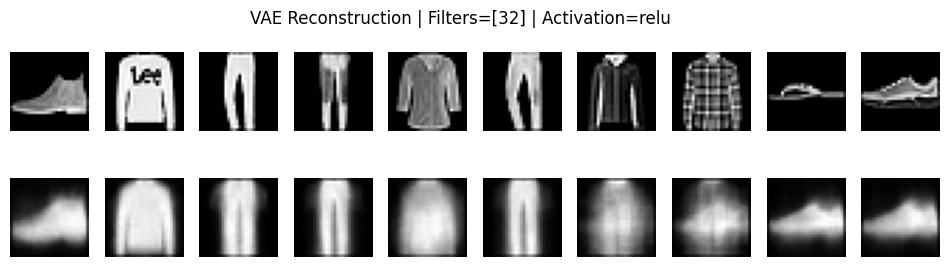

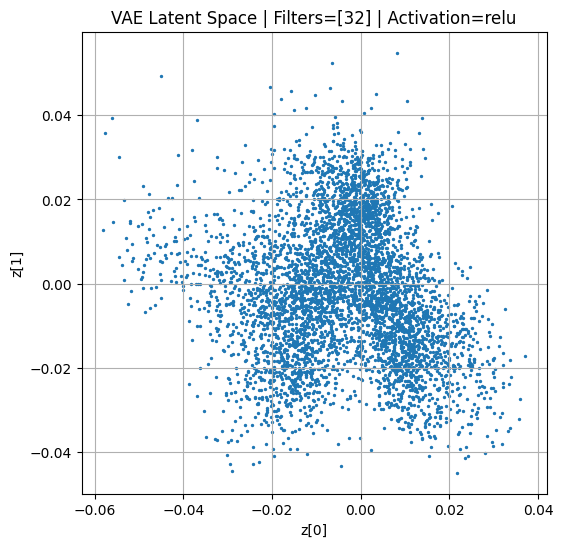

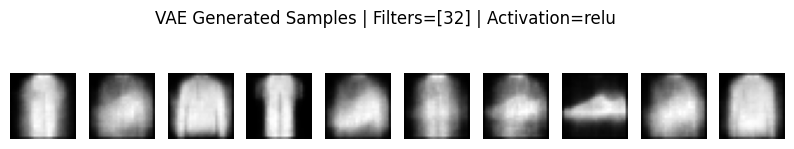


Architecture: Filters=[32, 64] | Activation=relu
Training Autoencoder (AE)...
Epoch 1/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - loss: 0.0618 - val_loss: 0.0143
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0131 - val_loss: 0.0104
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0098 - val_loss: 0.0087
Epoch 4/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0083 - val_loss: 0.0076
Epoch 5/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0074 - val_loss: 0.0070
Epoch 6/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0068 - val_loss: 0.0066
Epoch 7/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0064 - val_loss: 0.0063
Epoch 8/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0061 - val_loss: 0.0061
Epoch 9/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0059 - val_loss: 0.0060
Epoch 10/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0057 - val_loss: 0.0058
Epoch 11/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss

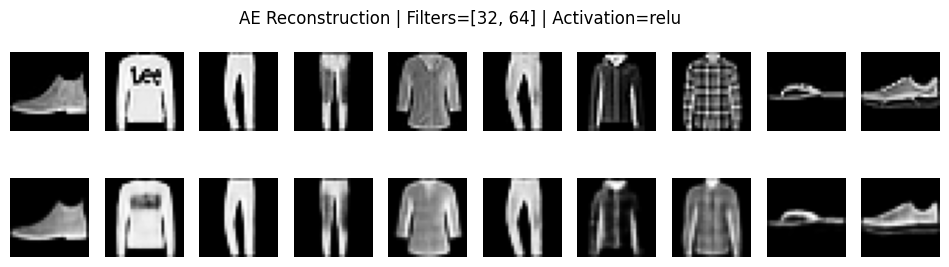

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


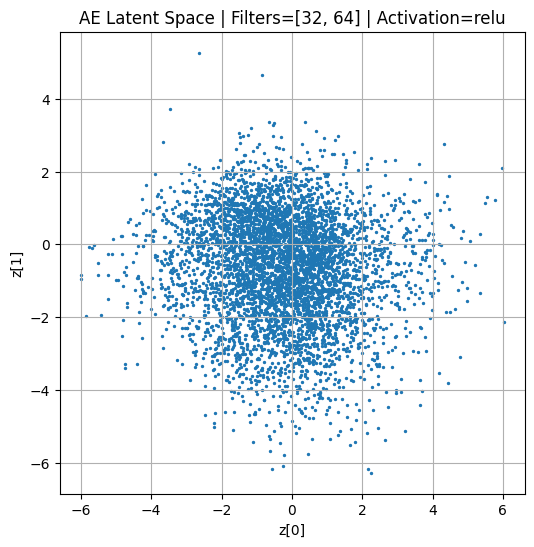

Training Variational Autoencoder (VAE)...
Epoch 1/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - kl_loss: 0.0032 - recon_loss: 0.1025 - val_kl_loss: 0.0097 - val_recon_loss: 0.0718
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - kl_loss: 0.0112 - recon_loss: 0.0696 - val_kl_loss: 0.0130 - val_recon_loss: 0.0652
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - kl_loss: 0.0142 - recon_loss: 0.0635 - val_kl_loss: 0.0153 - val_recon_loss: 0.0600
Epoch 4/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - kl_loss: 0.0168 - recon_loss: 0.0584 - val_kl_loss: 0.0186 - val_recon_loss: 0.0558
Epoch 5/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - kl_loss: 0.0180 - recon_loss: 0.0566 - val_kl_loss: 0.0187 - val_recon_loss: 0.0558
Epoch 6/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - kl_loss: 0.0183 - recon_loss: 0.0558 - val_kl_loss: 0.0191 - val_recon_loss: 0.0550
Epoch 7/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - kl_loss: 0.0188 - recon_loss: 0.0551 - val_kl_loss: 0.0180 - val_recon_los

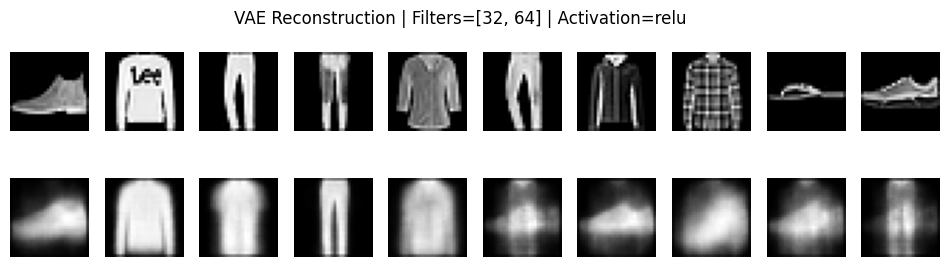

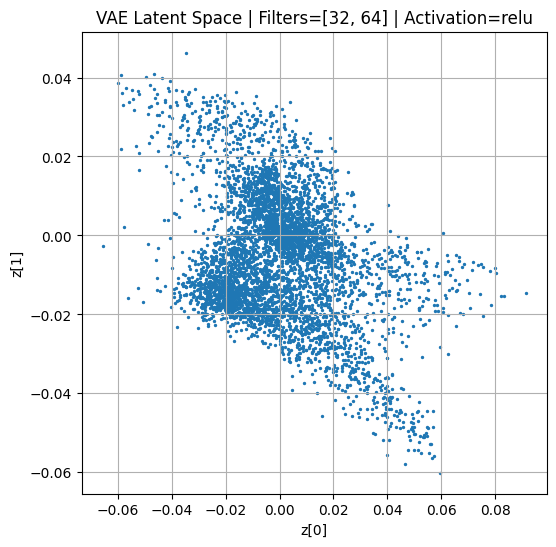

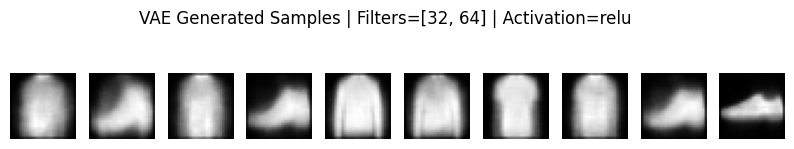


Architecture: Filters=[32, 64] | Activation=leaky_relu
Training Autoencoder (AE)...
Epoch 1/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 0.0591 - val_loss: 0.0128
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0114 - val_loss: 0.0088
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0083 - val_loss: 0.0074
Epoch 4/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0071 - val_loss: 0.0067
Epoch 5/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0065 - val_loss: 0.0062
Epoch 6/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0061 - val_loss: 0.0060
Epoch 7/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0058 - val_loss: 0.0058
Epoch 8/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0056 - val_loss: 0.0056
Epoch 9/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0054 - val_loss: 0.0055
Epoch 10/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0053 - val_loss: 0.0054
Epoch 11/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step 

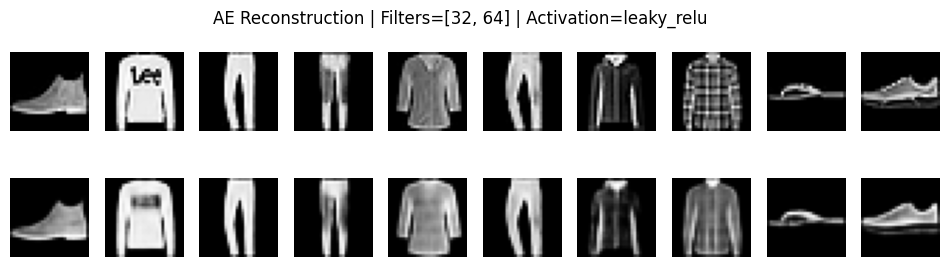

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


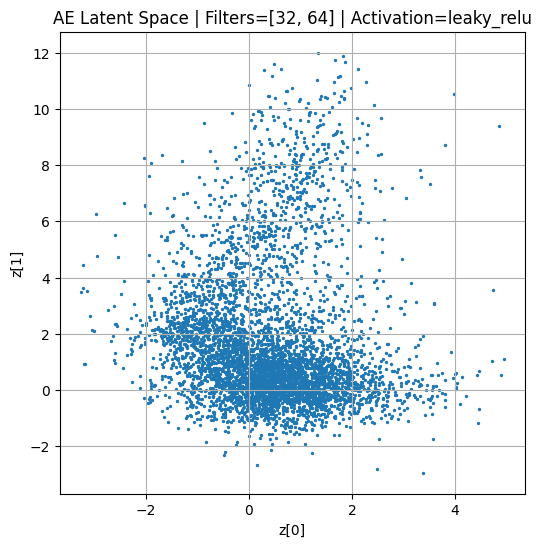

Training Variational Autoencoder (VAE)...
Epoch 1/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - kl_loss: 0.0066 - recon_loss: 0.0956 - val_kl_loss: 0.0129 - val_recon_loss: 0.0683
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - kl_loss: 0.0120 - recon_loss: 0.0682 - val_kl_loss: 0.0150 - val_recon_loss: 0.0614
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - kl_loss: 0.0164 - recon_loss: 0.0594 - val_kl_loss: 0.0173 - val_recon_loss: 0.0585
Epoch 4/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - kl_loss: 0.0175 - recon_loss: 0.0573 - val_kl_loss: 0.0190 - val_recon_loss: 0.0556
Epoch 5/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - kl_loss: 0.0180 - recon_loss: 0.0561 - val_kl_loss: 0.0192 - val_recon_loss: 0.0550
Epoch 6/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - kl_loss: 0.0186 - recon_loss: 0.0557 - val_kl_loss: 0.0184 - val_recon_loss: 0.0555
Epoch 7/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - kl_loss: 0.0190 - recon_loss: 0.0552 - val_kl_loss: 0.0166 - val_recon_los

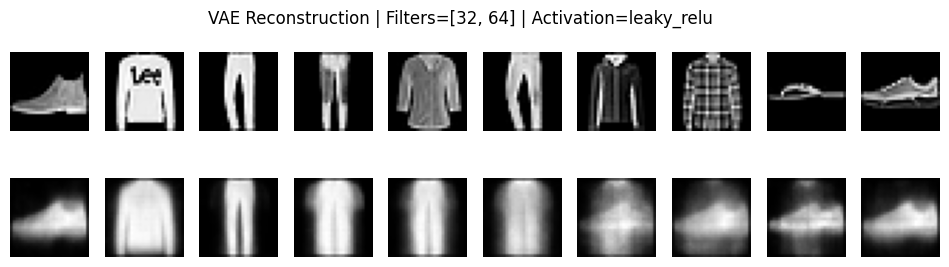

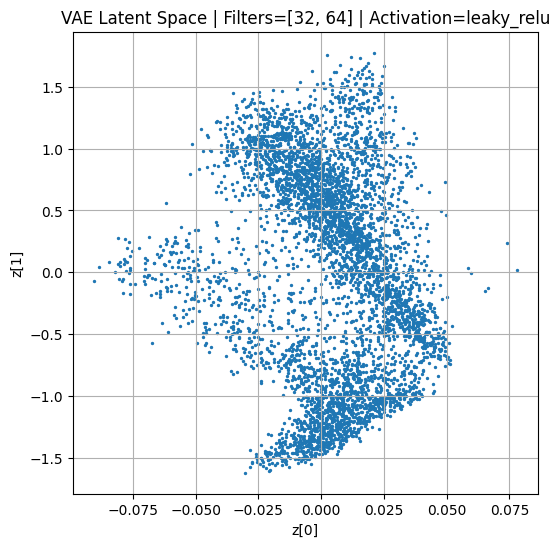

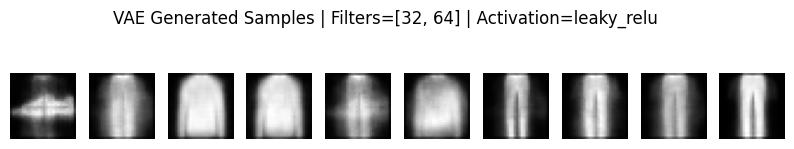

In [30]:

architectures = [
    {"filters": [32], "activation": "relu"},
    {"filters": [32, 64], "activation": "relu"},
    {"filters": [32, 64], "activation": "leaky_relu"},
]

for arch in architectures:
    print("\n" + "=" * 60)
    print(f"Architecture: Filters={arch['filters']} | Activation={arch['activation']}")
    print("=" * 60)

    print("Training Autoencoder (AE)...")

    ae, ae_encoder, _ = build_ae(
        latent_dim=64,
        filters=arch["filters"],
        activation=arch["activation"]
    )

    ae.fit(
        x_train,
        x_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=0.2,
        verbose=1
    )

    plot_reconstruction(
        ae,
        f"AE Reconstruction | Filters={arch['filters']} | Activation={arch['activation']}"
    )

    z_ae = ae_encoder.predict(x_test[:5000])

    plt.figure(figsize=(6,6))
    plt.scatter(z_ae[:,0], z_ae[:,1], s=2)
    plt.xlabel("z[0]")
    plt.ylabel("z[1]")
    plt.title(
        f"AE Latent Space | Filters={arch['filters']} | Activation={arch['activation']}"
    )
    plt.grid(True)
    plt.show()

    print("Training Variational Autoencoder (VAE)...")

    vae = VAE(
        latent_dim=64,
        filters=arch["filters"],
        activation=arch["activation"]
    )

    vae.compile(
        optimizer=tf.keras.optimizers.Adam(LEARNING_RATE)
    )

    vae.fit(
        x_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=0.2,
        verbose=1
    )
    plot_reconstruction(
        vae,
        f"VAE Reconstruction | Filters={arch['filters']} | Activation={arch['activation']}"
    )

    z_mean, _, _ = vae.encode(x_test[:5000])

    plt.figure(figsize=(6,6))
    plt.scatter(z_mean[:,0], z_mean[:,1], s=2)
    plt.xlabel("z[0]")
    plt.ylabel("z[1]")
    plt.title(
        f"VAE Latent Space | Filters={arch['filters']} | Activation={arch['activation']}"
    )
    plt.grid(True)
    plt.show()

    z = np.random.normal(size=(10, 64))
    gen = vae.decode(z)

    plt.figure(figsize=(10,2))
    for i in range(10):
        plt.subplot(1,10,i+1)
        plt.imshow(gen[i].numpy().squeeze(), cmap="gray")
        plt.axis("off")

    plt.suptitle(
        f"VAE Generated Samples | Filters={arch['filters']} | Activation={arch['activation']}"
    )
    plt.show()


Observations (Architecture Variations)
---



1.   When the number of convolutional layers and filters is increased, the reconstruction quality improves. This happens because deeper models can capture more detailed features from the images.
2.   Using ReLU and LeakyReLU activation functions gives similar overall performance. However, LeakyReLU produces slightly smoother reconstructions, as it helps avoid the problem of inactive (dead) neurons.
1.   The Autoencoder (AE) learns a latent space, but the representations are more scattered and less structured, which limits its ability to generate new meaningful samples.
2.   The Variational Autoencoder (VAE) learns a more organized and continuous latent space across different architectures.


1.   Because of this structured latent space, the VAE is able to generate realistic new samples, while the AE mainly focuses on reconstruction and does not support effective generation.












